# Visualization of Imputation Results

This notebook reads the exported result files from `GNL_clean.ipynb` and produces three plots:

1. **Scatter plot** — predicted (imputed) vs. true withheld IC50 values
2. **Rank-dependency plot** — Pearson/Spearman correlation as a function of low-rank approximation rank
3. **Optimal rank** — marks the optimal rank (≥95% cumulative variance) on the rank-dependency plot

**Files read** (all from `../output/`):
| File | Contents |
|------|----------|
| `imputed_ic50-{key}_{type}.csv` | antibody, virus, true IC50, imputed IC50 (withheld entries only) |
| `rank_dependency_id-{key}_{type}.txt` | rank, Pearson, Spearman (space-delimited, includes `Full` row) |
| `rank_dependency_optimal_id-{key}_{type}.txt` | optimal rank, method, Pearson, Spearman |

> **Note:** The prompt suggested filenames `imputed_vs_withheld.csv`, `rank_dependency.csv`,
> and `optimized_parameters.csv`, but the actual output uses the pattern above.
> Set `file_key` and `DATA_TYPE` below to match the run you want to visualize.


In [2]:
using CSV, DataFrames, Printf, Plots, Statistics, StatsBase

## Configuration

Set `file_key` and `DATA_TYPE` to match the simulation run you want to visualize.


In [3]:
DIR_OUT   = "../output"
file_key  = "test"    # must match the file_key used in GNL_clean.ipynb
DATA_TYPE = "IC50"    # "IC50" | "IC80" | "HillCoeff" | "IIP"

# Derived file paths
fname_imputed     = @sprintf("%s/imputed_ic50-%s_%s.csv",              DIR_OUT, file_key, DATA_TYPE)
fname_rank        = @sprintf("%s/rank_dependency_id-%s_%s.txt",        DIR_OUT, file_key, DATA_TYPE)
fname_rank_opt    = @sprintf("%s/rank_dependency_optimal_id-%s_%s.txt", DIR_OUT, file_key, DATA_TYPE)

"../output/rank_dependency_optimal_id-test_IC50.txt"

In [4]:
# Load imputed vs. withheld values
df_imputed = CSV.read(fname_imputed, DataFrame)

# Load rank-dependency table (skip the last 'Full' row for numeric plotting)
df_rank_raw = CSV.read(fname_rank, DataFrame, delim=' ')
df_rank     = filter(row -> row.rank != "Full", df_rank_raw)
df_rank[!, :rank]        = parse.(Int,     df_rank.rank)
df_rank[!, :Pearson_GLR] = df_rank.Pearson_GLR
df_rank[!, :Spearman_GLR]= df_rank.Spearman_GLR

# Correlation at full rank (no low-rank truncation)
df_rank_full = filter(row -> row.rank == "Full", df_rank_raw)
r_full_pearson  = df_rank_full.Pearson_GLR[1]
r_full_spearman = df_rank_full.Spearman_GLR[1]

# Load optimal rank
df_opt       = CSV.read(fname_rank_opt, DataFrame, delim=' ')
rank_opt     = df_opt.rank[1]
r_opt_pearson  = parse(Float64, string(df_opt.Pearson[1]))
r_opt_spearman = parse(Float64, string(df_opt.Spearman[1]))

@printf("Loaded %d withheld entries for scatter plot\n", nrow(df_imputed))
@printf("Optimal rank: %d  (Pearson=%.3f, Spearman=%.3f)\n", rank_opt, r_opt_pearson, r_opt_spearman)

Loaded 8083 withheld entries for scatter plot
Optimal rank: 21  (Pearson=0.822, Spearman=0.817)


## Plot 1: Predicted vs. True Withheld Values

Each point is one withheld (antibody, virus) entry.
A perfect imputation would lie on the diagonal.


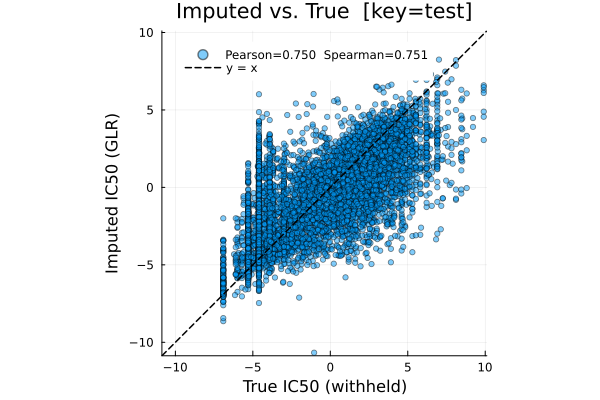

In [5]:
true_vals    = float.(df_imputed.true_ic50)
imputed_vals = float.(df_imputed.imputed_ic50_GLR)

r_pearson  = round(cor(true_vals, imputed_vals), digits=3)
r_spearman = round(corspearman(true_vals, imputed_vals), digits=3)

lims = (minimum([true_vals; imputed_vals]) - 0.2,
        maximum([true_vals; imputed_vals]) + 0.2)

scatter(true_vals, imputed_vals,
    xlabel     = "True $(DATA_TYPE) (withheld)",
    ylabel     = "Imputed $(DATA_TYPE) (GLR)",
    title      = "Imputed vs. True  [key=$(file_key)]",
    label      = @sprintf("Pearson=%.3f  Spearman=%.3f", r_pearson, r_spearman),
    markersize = 3, alpha = 0.5, foreground_color_legend = nothing, 
    xlims = lims, ylims = lims,
    legend = :topleft, aspect_ratio = :equal)
plot!([lims[1], lims[2]], [lims[1], lims[2]],
    label = "y = x", color = :black, linestyle = :dash, linewidth = 1.5)

## Plots 2 & 3: Rank-Dependency and Optimal Rank

Pearson and Spearman correlation vs. the rank used for the low-rank SVD approximation.
The vertical dashed line marks the optimal rank (≥95% cumulative variance).
Horizontal dotted lines show the full-rank (no truncation) performance.


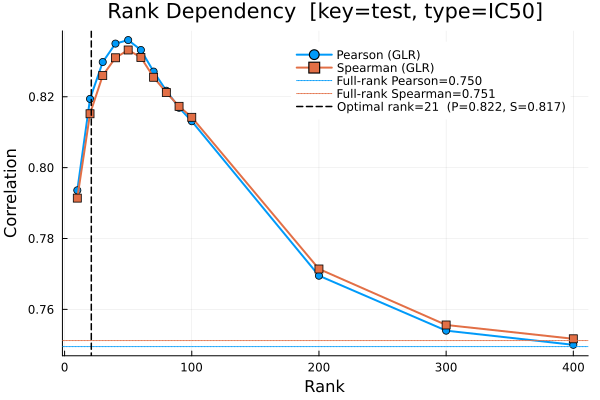

In [6]:
ranks    = df_rank.rank
pearson  = df_rank.Pearson_GLR
spearman = df_rank.Spearman_GLR

p = plot(ranks, pearson,
    label     = "Pearson (GLR)",
    xlabel    = "Rank",
    ylabel    = "Correlation",
    title     = "Rank Dependency  [key=$(file_key), type=$(DATA_TYPE)]",
    marker    = :circle, markersize = 4,
    linewidth = 2, legend = :bottomright)

plot!(p, ranks, spearman,
    label = "Spearman (GLR)",
    marker = :square, markersize = 4, linewidth = 2, foreground_color_legend = nothing, legend=:topright)

# Full-rank reference lines
hline!(p, [r_full_pearson],  linestyle = :dot, color = 1,
    label = @sprintf("Full-rank Pearson=%.3f", r_full_pearson))
hline!(p, [r_full_spearman], linestyle = :dot, color = 2,
    label = @sprintf("Full-rank Spearman=%.3f", r_full_spearman))

# Optimal rank
vline!(p, [rank_opt], linestyle = :dash, color = :black, linewidth = 1.5,
    label = @sprintf("Optimal rank=%d  (P=%.3f, S=%.3f)", rank_opt, r_opt_pearson, r_opt_spearman))

p